1. Complete-care analysis (CCA), consists in discarding observations(row) where values in any of the variables (col) are missing.
2. CCA means analyzing  only those observations for which there is information in all variables.



when use CCA on numerical data,try drawing histograph of new and old data : the graph looks similar >> CCA successfull

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r'c:\Users\rajku\Downloads\data_science_job.csv')

In [4]:
df.head()
# df.shape

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [5]:
df.isnull().mean()*100          # percentage of missing values

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

CCA can be apply on those colums where missing values are less than 5%

In [6]:
cols = [var for var in df.columns if df[var].isnull().mean() < 0.05 and df[var].isnull().mean() > 0]
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [11]:
df[cols].sample(8)

,city_development_index,enrolled_university,education_level,experience,training_hours
7566,0.926,no_enrollment,Graduate,9.0,NaN
12841,0.624,no_enrollment,Graduate,0.0,26.0
18813,0.624,Full time course,Graduate,1.0,25.0
6159,0.802,Full time course,Graduate,3.0,92.0
7845,0.624,Part time course,High School,1.0,96.0
10540,0.923,Full time course,Graduate,11.0,44.0
9056,0.910,no_enrollment,Graduate,14.0,51.0
11018,0.743,no_enrollment,Masters,9.0,146.0


In [ ]:
len(df[cols].dropna()) / len(df)  *100      # data remaining in percentag

89.68577095730244

In [9]:

print(df.shape)
new_df = df[cols].dropna()
new_df.shape , df[cols].shape

(19158, 13)


((17182, 5), (19158, 5))

<Axes: >

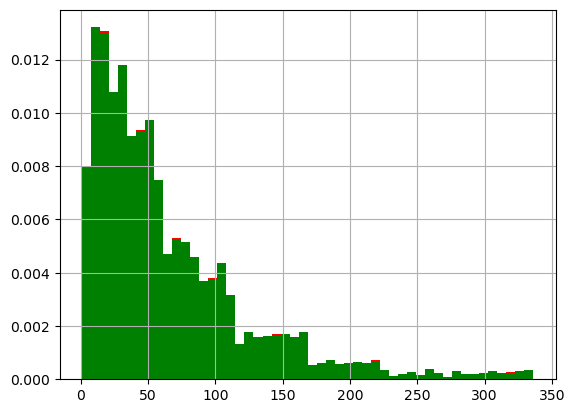

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)
df['training_hours'].hist(bins=50, ax=ax, density=True, color='red')
new_df['training_hours'].hist(bins=50, ax=ax, density=True, color='green')
# overlapping area means perfectly CAA appplied